<font face='Calibri' size=7 color='#add8e6'>**💎 Diamond Price  〽️ Forecast**</font>

#<font face='Calibri' color="#add8e6">**Data Preparation** </font>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
table_style = {
    "border": "1px solid black",
    "text-align": "center",
    "border-collapse": "collapse",
    "font-size": "14px",
    "background-color": "w"
}

In [20]:
df = pd.read_csv('/content/drive/MyDrive/Test/Csv/diamonds.csv')
print(f"Shape of dataset {df.shape}")
print('Glimpe of dataset')
df.head().style.set_properties(**table_style)


Shape of dataset (53940, 11)
Glimpe of dataset


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.230000,Ideal,E,SI2,61.500000,55.000000,326,3.950000,3.980000,2.430000
1,2,0.210000,Premium,E,SI1,59.800000,61.000000,326,3.890000,3.840000,2.310000
2,3,0.230000,Good,E,VS1,56.900000,65.000000,327,4.050000,4.070000,2.310000
3,4,0.290000,Premium,I,VS2,62.400000,58.000000,334,4.200000,4.230000,2.630000
4,5,0.310000,Good,J,SI2,63.300000,58.000000,335,4.340000,4.350000,2.750000



*   Drop Column "Unnamed: 0" (couse Unnamed just an index number)


In [21]:
df = df.drop(columns=['Unnamed: 0'])
df.head().style.set_properties(**table_style)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.230000,Ideal,E,SI2,61.500000,55.000000,326,3.950000,3.980000,2.430000
1,0.210000,Premium,E,SI1,59.800000,61.000000,326,3.890000,3.840000,2.310000
2,0.230000,Good,E,VS1,56.900000,65.000000,327,4.050000,4.070000,2.310000
3,0.290000,Premium,I,VS2,62.400000,58.000000,334,4.200000,4.230000,2.630000
4,0.310000,Good,J,SI2,63.300000,58.000000,335,4.340000,4.350000,2.750000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [26]:
df.isnull().sum().to_frame().T.style.set_properties(**table_style)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0,0,0,0,0,0,0,0,0,0


In [24]:
df.describe().style.set_properties(**table_style)

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [29]:
print(f"Shape of dataset {df.shape}")
df.describe(include="object").T.style.set_properties(**table_style)

Shape of dataset (53940, 10)


,count,unique,top,freq
cut,53940,5,Ideal,21551
color,53940,7,G,11292
clarity,53940,8,SI1,13065


In [30]:
duplicate_data = df.duplicated().sum()
print(f"Number of duplicate data: {duplicate_data}")

Number of duplicate data: 146




*   The dataset have an 146 duplicate datas
*   Now we will drop the duplicated data

In [32]:
df.drop_duplicates(inplace=True)
duplicate_data = df.duplicated().sum()
print(f"Number of duplicate data: {duplicate_data}")
print(f"Shape of dataset {df.shape}")

Number of duplicate data: 0
Shape of dataset (53794, 10)


Insight The dataset


*   have no null values
*   have 146 duplicat data (already drop)
*   Data from 53.940 to 53.794



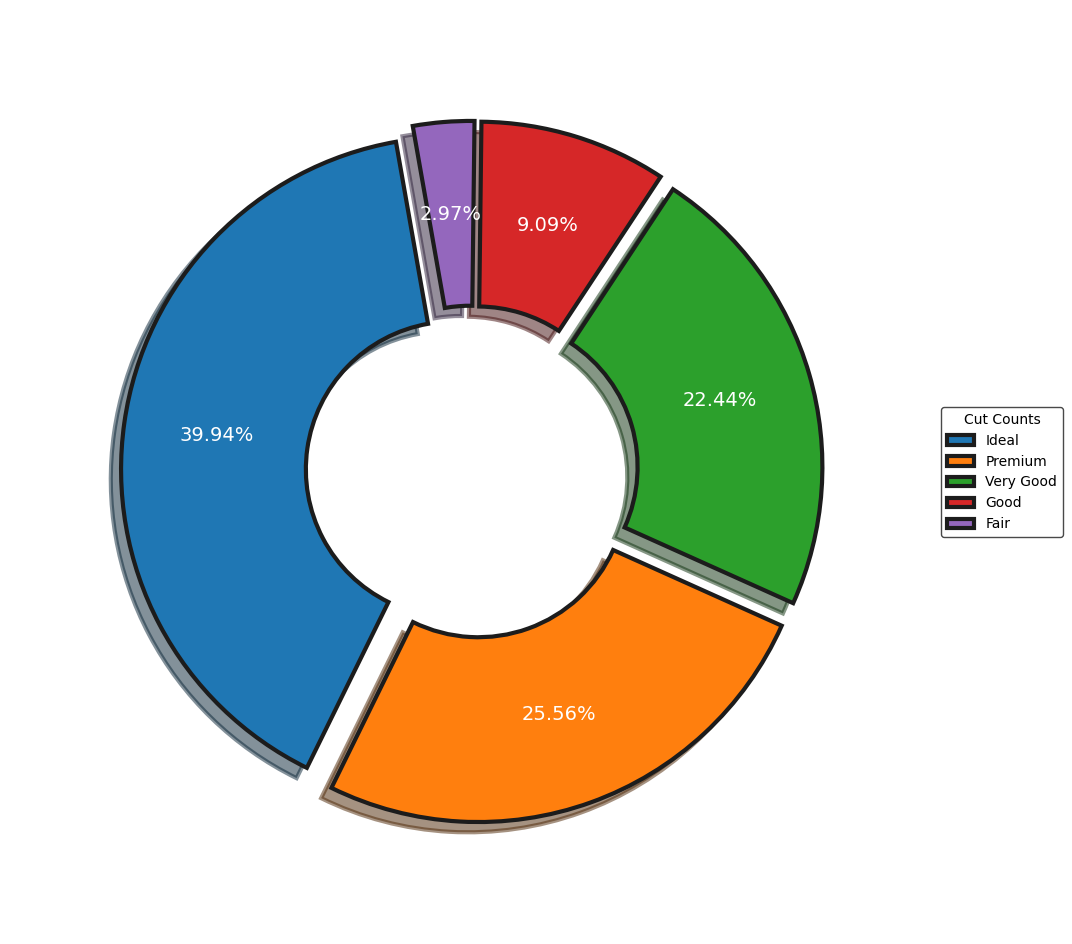

In [47]:
cut_count = df.cut.value_counts()
plt.subplots(figsize=(12,12))
Label = "Ideal", "Premium", "Very Good", "Good", "Fair"
size = 0.5
wedges, texts, autotexts = plt.pie([cut_count.iloc[0], cut_count.iloc[1], cut_count.iloc[2], cut_count.iloc[3], cut_count.iloc[4]],
                                   explode=(0.05, 0.05, 0.05, 0.05, 0.05),
                                   autopct='%.2f%%',
                                   shadow=True,
                                   pctdistance=0.72,
                                   radius=.9,
                                   wedgeprops=dict(width=size, edgecolor='#1c1c1c', linewidth=3),
                                   textprops=dict(color="white", size=14),
                                   startangle=100)
plt.legend(wedges, Label, title='Cut Counts', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), edgecolor="#1c1c1c")
plt.show()

Let's have a look on the diamond's cut :


<ipython-input-45-aabc74060e08>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  p=sns.countplot(y=df["cut"],order=df["cut"].value_counts().index,palette=["#3f4f45","#5e9880","#f5a126","#ea5b17","#6c3938"], saturation=1, edgecolor = "#1c1c1c", linewidth = 5)
<ipython-input-45-aabc74060e08>:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)


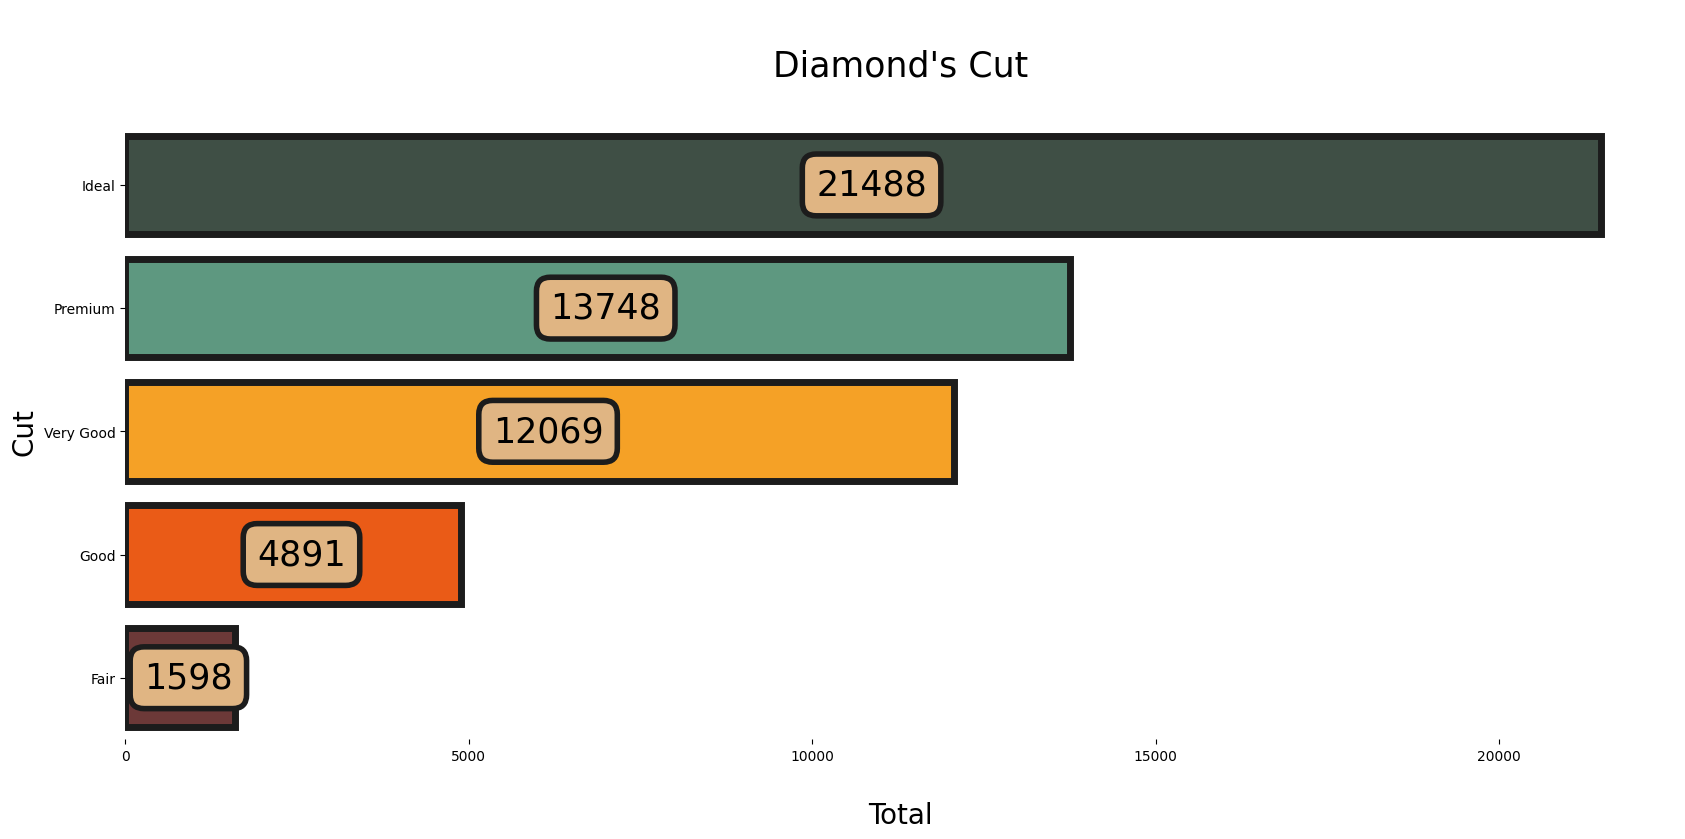

In [45]:
print("Let's have a look on the diamond's cut :")
plt.subplots(figsize=(20, 8))
p=sns.countplot(y=df["cut"],order=df["cut"].value_counts().index,palette=["#3f4f45","#5e9880","#f5a126","#ea5b17","#6c3938"], saturation=1, edgecolor = "#1c1c1c", linewidth = 5)
# p.axes.set_yscale("symlog")
p.axes.set_title("\nDiamond's Cut\n",fontsize=25)
p.axes.set_ylabel("Cut",fontsize=20)
p.axes.set_xlabel("\nTotal",fontsize=20)
p.axes.set_yticklabels(p.get_yticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=25,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.4, "facecolor": "#e0b583", "edgecolor": "#1c1c1c", "linewidth" : 4, "alpha": 1})


sns.despine(left=True, bottom=True)
plt.show()